<a href="https://colab.research.google.com/github/joaocanaslopes/Assignments_ML/blob/main/Assignment1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. IMPORTS


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
data = pd.read_csv(url, sep=";")

print(data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

In [3]:
X = data.drop("quality", axis=1).values  # input
y = data["quality"].values.reshape(-1,1) # output

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train dataset size:", X_train.shape)
print("Test dataset size:", X_test.shape)

Train dataset size: (3918, 11)
Test dataset size: (980, 11)


In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [6]:
class WineModel(nn.Module):
    def __init__(self):
        super(WineModel, self).__init__()
        self.linear1 = nn.Linear(X_train.shape[1], 64)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

model = WineModel()

In [7]:
criterion = nn.MSELoss()

In [8]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [9]:
epochs = 100          # EPOCH: number of full passes over training dataset
batch_size = 32       # BATCH: number of samples per update

loss_history = []

In [11]:
for epoch in range(epochs):

    permutation = torch.randperm(X_train.size()[0])

    for i in range(0, X_train.size()[0], batch_size):

        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]

        # Forward pass (PREDICT)
        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_history.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.3814
Epoch [20/100], Loss: 0.2666
Epoch [30/100], Loss: 0.3570
Epoch [40/100], Loss: 0.5996
Epoch [50/100], Loss: 0.3613
Epoch [60/100], Loss: 0.2962
Epoch [70/100], Loss: 0.2557
Epoch [80/100], Loss: 0.4554
Epoch [90/100], Loss: 0.2833
Epoch [100/100], Loss: 0.1782


In [12]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)

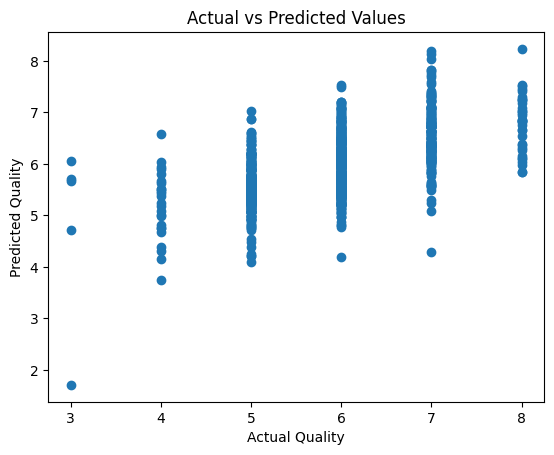

In [13]:
plt.figure()
plt.scatter(y_test.numpy(), predictions.numpy())
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Values")
plt.show()

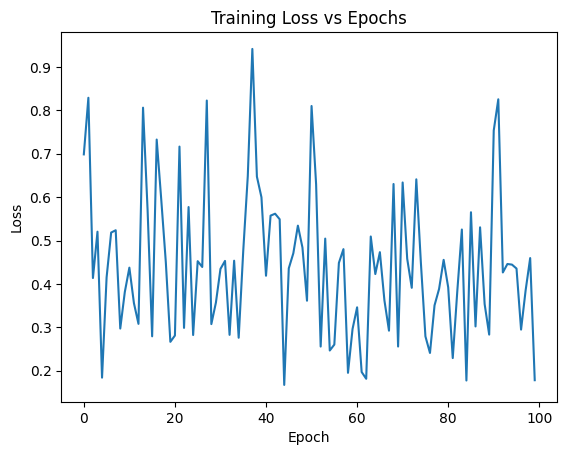

In [14]:
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()